En una planta automotriz, las fallas imprevistas en las prensas hidr´aulicas cr´ıticas generan detenciones en la línea que cuestan miles de dólares por minuto. El departamento de Mantenimiento y
Confiabilidad ha instrumentado una de las máquinas principales para capturar métricas clave.El dataset contiene 1,000 registros históricos y ha sido perfectamente balanceado (500 casos estables y 500 eventos de fallo crítico) para estructurar un modelo predictivo base sin sesgo inicial de clase. A continuación, la siguiente tabla muestra las variables registradas (pestaña Clasificacion Mantenimiento).

a) Entrene un modelo XGBoost realizando una validación cruzada con K = 5. Justifique la elección de hiperparámetros.

b) Extraiga y documente el promedio y la desviación estándar de las siguientes métricas evaluadas a través de las 5 iteraciones: Accuracy, Precision, Recall y F1-Score.

c) Interpretación Industrial Relativa: Si bien el dataset es balanceado para este entrenamiento, en la operación real de la planta las fallas corresponden a menos del 2% del tiempo total. Explique de forma crítica por qué una métrica de Exactitud alta no es suficiente en entornos productivos industriales reales. Asimismo, determine fundadamente en qué métrica específica debe enfocarse el líder de planta si su prioridad estratégica es minimizar los paros no programados (evitar Falsos Negativos), asumiendo el costo menor de inspeccionar falsas alarmas.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import openpyxl 
from sklearn import metrics
import xgboost as xgb


ruta_exel = r'C:\Users\Vanhertz\Downloads\datasets_evaluacion3.xlsx'
datos = pd.read_excel(ruta_exel, header=0)
datos.describe()


**Crear y hacer splitting de X e Y**

In [7]:
#crear X,Y
X = datos.iloc[:, [0,1,2,4]].values # se sacan los entereos pues solo podemos usar variables continuas
y = datos.iloc[:, 5].values

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.30,stratify=y,random_state=1) 
#siempre lo mismo como en las otras clases.
#para crear conjuntos de entrenamiento y prueba
#X

In [8]:
#entrenamos el modelo con XGBoost usando make pipe
from sklearn.pipeline import make_pipeline               #es necesario para hacer un pipeline, que es una forma de concatenar proceso
pipe_xgb = make_pipeline(StandardScaler(), xgb.XGBClassifier(n_estimators=3, max_depth=3, learning_rate=0.05, objective='binary:logistic'))
pipe_xgb.fit(X_train, y_train)      #con esto entrenamos el modelo con los datos de entrenamiento

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [9]:
# Validacion cruzada StratifiedKFold
#se tiene que estandarizar porque los valores de las variables son muy diferentes, es para que no tengan un peso mayor en el modelo
#valores entre 59 y 106 en grados y 0.09 a 8.13 en vibracion, si o si hay que estandarizar.
#en este caso por comodidad usamos los codigos de la clase 18 para crear un pipeline

from sklearn.model_selection import StratifiedKFold       

kfold = StratifiedKFold(n_splits=5).split(X_train, y_train)
model_xgb = xgb.XGBClassifier(n_estimators=2, max_depth=3, learning_rate=0.01, objective='binary:logistic')

scores = []
for k, (train, test) in enumerate(kfold):
    pipe_temp = make_pipeline(StandardScaler(),model_xgb)     # se cambio logistic regression por xgboost y lr por temp(pues sera solo dentro del for)
    pipe_temp.fit(X_train[train], y_train[train])
    score = pipe_temp.score(X_train[test], y_train[test])
    scores.append(score)
    print('Fold: %2d, Class dist train.: %s, Class dist test.: %s, Acc: %.3f' % (k+1,np.bincount(y_train[train]),
                                                                                 np.bincount(y_train[test]), score))
    
print('\nCV accuracy: %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

Fold:  1, Class dist train.: [280 280], Class dist test.: [70 70], Acc: 1.000
Fold:  2, Class dist train.: [280 280], Class dist test.: [70 70], Acc: 1.000
Fold:  3, Class dist train.: [280 280], Class dist test.: [70 70], Acc: 1.000
Fold:  4, Class dist train.: [280 280], Class dist test.: [70 70], Acc: 1.000
Fold:  5, Class dist train.: [280 280], Class dist test.: [70 70], Acc: 0.986

CV accuracy: 0.997 +/- 0.006


In [10]:
#para evaluar el modelo se debe usar el codigo de la clase 18 tambien:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import matthews_corrcoef,cohen_kappa_score
from sklearn.metrics import confusion_matrix

y_pred = pipe_xgb.predict(X_test)

confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

print('Accuracy (ec. 2): %.3f' % accuracy_score(y_true=y_test, y_pred=y_pred))
print('Precision (ec. 5): %.3f' % precision_score(y_true=y_test, y_pred=y_pred))
print('Recall (ec. 6): %.3f' % recall_score(y_true=y_test, y_pred=y_pred))
print('F1 (ec. 9): %.3f' % f1_score(y_true=y_test, y_pred=y_pred))
print('MCC (ec. 10): %.3f' % matthews_corrcoef(y_true=y_test, y_pred=y_pred))
print('Kappa (ec. 11): %.3f' % cohen_kappa_score(y1=y_test, y2=y_pred))


[[150   0]
 [  0 150]]
Accuracy (ec. 2): 1.000
Precision (ec. 5): 1.000
Recall (ec. 6): 1.000
F1 (ec. 9): 1.000
MCC (ec. 10): 1.000
Kappa (ec. 11): 1.000


## b) Extracción de Precision, Recall y F1-Score por fold

El loop anterior solo calcula Accuracy. A continuación se extraen las 4 métricas requeridas por el enunciado en cada fold


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Se declara un nuevo iterador (el anterior ya fue consumido)
kfold_metrics = StratifiedKFold(n_splits=5).split(X_train, y_train)
model_xgb_metrics = xgb.XGBClassifier(n_estimators=2, max_depth=3, learning_rate=0.01, objective='binary:logistic')

scores_acc  = []
scores_prec = []
scores_rec  = []
scores_f1   = []

for k, (train, test) in enumerate(kfold_metrics):
    pipe_temp = make_pipeline(StandardScaler(), model_xgb_metrics)
    pipe_temp.fit(X_train[train], y_train[train])
    y_pred_fold = pipe_temp.predict(X_train[test])

    acc  = accuracy_score(y_train[test],  y_pred_fold)
    prec = precision_score(y_train[test], y_pred_fold)
    rec  = recall_score(y_train[test],    y_pred_fold)
    f1   = f1_score(y_train[test],        y_pred_fold)

    scores_acc.append(acc)
    scores_prec.append(prec)
    scores_rec.append(rec)
    scores_f1.append(f1)

    print('Fold: %2d, Class dist train.: %s, Class dist test.: %s, Acc: %.3f' % (
        k+1, np.bincount(y_train[train]), np.bincount(y_train[test]), acc))

print('\nCV Accuracy:  %.3f +/- %.3f' % (np.mean(scores_acc),  np.std(scores_acc)))
print('CV Precision: %.3f +/- %.3f' % (np.mean(scores_prec), np.std(scores_prec)))
print('CV Recall:    %.3f +/- %.3f' % (np.mean(scores_rec),  np.std(scores_rec)))
print('CV F1-Score:  %.3f +/- %.3f' % (np.mean(scores_f1),   np.std(scores_f1)))

## c) Interpretación Industrial Relativa

**¿Por qué la Exactitud (Accuracy) no es suficiente en entornos industriales reales?**

En la operación real de la planta, las fallas ocurren en **menos del 2% del tiempo total**. Esto crea un fuerte desbalance de clases: por cada fallo real hay aproximadamente 49 operaciones normales. En ese escenario, un modelo que prediga siempre *'Operación Estable'* obtiene más del 98% de Accuracy sin detectar ninguna falla real. La métrica es engañosa porque recompensa el sesgo hacia la clase mayoritaria.

**¿En qué métrica debe enfocarse el líder de planta?**

La prioridad estratégica es **minimizar los paros no programados**, es decir, evitar los **Falsos Negativos** (el modelo predice 'Estable' pero la máquina va a fallar). La métrica que captura esto directamente es el **Recall (Exhaustividad)**:

$$\\text{Recall} = \\frac{TP}{TP + FN}$$

Un Recall alto garantiza que la mayoría de los fallos reales sean detectados a tiempo. El costo de una falsa alarma (inspección innecesaria) es significativamente menor que el costo de un paro de línea no anticipado, por lo tanto se prioriza Recall sobre Precisión.

## Problema 2: Regresión — Eficiencia de Consumo Energético

Una planta de fundición siderúrgica busca automatizar la estimación de costos energéticos en hornos de arco eléctrico. Se registraron 1,000 lotes de producción con variables operativas y el consumo total en kWh.

In [ ]:
# Cargamos la pestaña de regresión desde el mismo archivo Excel
datos2 = pd.read_excel(ruta_exel, sheet_name='Regresion_ConsumoEnergia', header=0)
datos2.describe()

**Crear y hacer splitting de X e Y para regresión**

In [ ]:
#crear X2, Y2
X2 = datos2.iloc[:, [0,1,2,3]].values   # lote, horas, defectos, temperatura (todas las predictoras)
y2 = datos2.iloc[:, 4].values            # consumo_energia_kwh (target)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30, random_state=1)
#sin stratify pues el target es continuo (no hay clases que balancear)

In [ ]:
#entrenamos el modelo con XGBoost Regressor usando make_pipeline
# se usa pipe_reg para no sobreescribir pipe_xgb del Problema 1
pipe_reg = make_pipeline(
    StandardScaler(),
    xgb.XGBRegressor(n_estimators=3, max_depth=3, learning_rate=0.05, objective='reg:squarederror')
)
pipe_reg.fit(X2_train, y2_train)

In [ ]:
# Validacion cruzada KFold para regresion
# se usa KFold (no StratifiedKFold) pues el target es continuo
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

kfold_reg = KFold(n_splits=5).split(X2_train, y2_train)

scores_mse  = []
scores_rmse = []
scores_r2   = []

for k, (train, test) in enumerate(kfold_reg):
    # se instancia el modelo dentro del loop, igual que el compañero en P1
    pipe_temp_reg = make_pipeline(
        StandardScaler(),
        xgb.XGBRegressor(n_estimators=3, max_depth=3, learning_rate=0.05, objective='reg:squarederror')
    )
    pipe_temp_reg.fit(X2_train[train], y2_train[train])
    y2_pred_fold = pipe_temp_reg.predict(X2_train[test])

    mse  = mean_squared_error(y2_train[test], y2_pred_fold)
    rmse = np.sqrt(mse)
    r2   = r2_score(y2_train[test], y2_pred_fold)

    scores_mse.append(mse)
    scores_rmse.append(rmse)
    scores_r2.append(r2)

    print('Fold: %2d, MSE: %.3f, RMSE: %.3f, R2: %.3f' % (k+1, mse, rmse, r2))

print('\nCV MSE:  %.3f +/- %.3f' % (np.mean(scores_mse),  np.std(scores_mse)))
print('CV RMSE: %.3f +/- %.3f' % (np.mean(scores_rmse), np.std(scores_rmse)))
print('CV R2:   %.3f +/- %.3f' % (np.mean(scores_r2),   np.std(scores_r2)))

In [ ]:
#para evaluar el modelo regresor sobre el conjunto de prueba:
y2_pred = pipe_reg.predict(X2_test)

print('MSE  (test): %.3f' % mean_squared_error(y2_test, y2_pred))
print('RMSE (test): %.3f' % np.sqrt(mean_squared_error(y2_test, y2_pred)))
print('R2   (test): %.3f' % r2_score(y2_test, y2_pred))

Prueba de que esto es online y no local

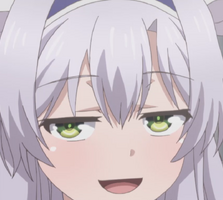

In [5]:
from IPython.display import Image

Image(filename=r'Character_Anime-Sistine~2.png', width=500)